### Mengambil Dataset dari Kaggle

In [47]:
!pip install kagglehub


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import kagglehub
path = kagglehub.dataset_download("ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training")

In [18]:
import os 

print(path)
print(os.listdir(path))

C:\Users\LENOVO\.cache\kagglehub\datasets\ahmedmohamed2003\cafe-sales-dirty-data-for-cleaning-training\versions\1
['dirty_cafe_sales.csv']


### Load Dataset

In [19]:
import pandas as pd
import numpy as np

df = pd.read_csv(path + "/dirty_cafe_sales.csv")
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [21]:
df.shape

(10000, 8)

In [25]:
df.isnull().sum()

Transaction ID         0
Item                 625
Quantity             308
Price Per Unit       369
Total Spent          337
Payment Method      2885
Location            3623
Transaction Date     301
dtype: int64

In [22]:
print(df['Item'].unique())
print(df['Location'].unique())
print(df['Payment Method'].unique())

['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'UNKNOWN' 'Sandwich' nan
 'ERROR' 'Juice' 'Tea']
['Takeaway' 'In-store' 'UNKNOWN' nan 'ERROR']
['Credit Card' 'Cash' 'UNKNOWN' 'Digital Wallet' 'ERROR' nan]


### A. Pengecekan sebelum dilakukan cleaning

#### Standarisasi

In [23]:
df.replace(['UNKOWN', 'ERROR'], np.nan, inplace=True)

In [24]:
(df.isnull().sum() / len(df)) * 100

Transaction ID       0.00
Item                 6.25
Quantity             3.08
Price Per Unit       3.69
Total Spent          3.37
Payment Method      28.85
Location            36.23
Transaction Date     3.01
dtype: float64

#### Cleaning

##### 1. Buang kolom location

In [26]:
df.drop(columns=['Location'], inplace=True)

### 2. Cleaning kolom item

In [27]:
df = df.dropna(subset=['Item'])
df['Item'].isnull().sum()

np.int64(0)

### 3. Cleaning Quantity, Price Per Unit

<Axes: >

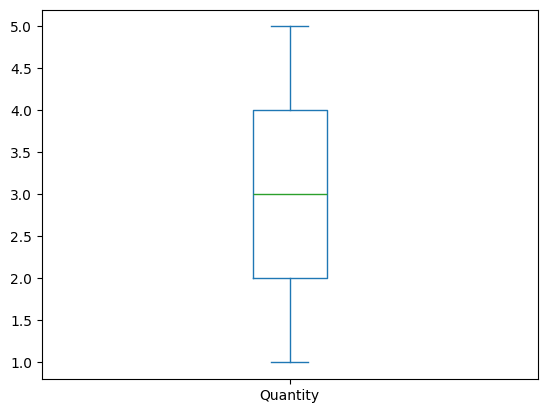

In [28]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Quantity'].plot(kind='box')

<Axes: >

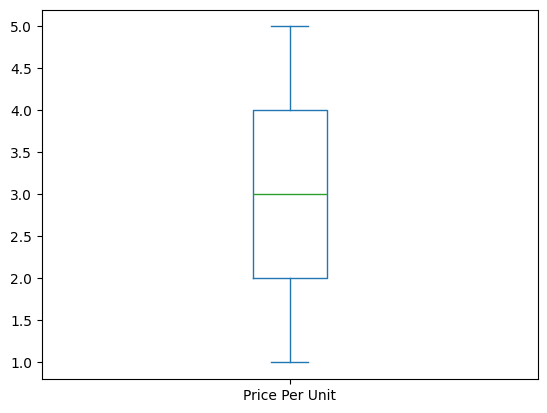

In [29]:
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Price Per Unit'].plot(kind='box')

In [30]:
df['Quantity'].fillna(df['Quantity'].mean(), inplace=True)
df['Price Per Unit'].fillna(df['Price Per Unit'].mean(), inplace=True)

df[['Price Per Unit', 'Quantity']].isnull().sum()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_1708\82779838.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Quantity'].fillna(df['Quantity'].mean(), inplace=True)


Price Per Unit    0
Quantity          0
dtype: int64

In [31]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,2023-06-11


In [32]:
df['Total Spent'] = df['Quantity'] * df['Price Per Unit']
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,2023-06-11


### 5. Cleaning Paymend Method

In [39]:
df['Payment Method'].fillna('Unknown', inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_1708\877762797.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Payment Method'].fillna('Unknown', inplace=True)


### 6. Cleaning & Formatting

In [50]:
df = df.dropna(subset=['Transaction Date'])
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

ValueError: time data "UNKNOWN" doesn't match format "%Y-%m-%d", at position 365. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [48]:
df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Transaction Date    0
dtype: int64

In [51]:
df.shape

(9092, 7)

### C. Mengecek Duplikasi

In [42]:
df.duplicated().sum()

np.int64(0)

### D. Sorting

In [43]:
df = df.sort_values(by='Transaction Date', ascending=True)
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Transaction Date
1777,TXN_7367474,Juice,5.000000,3.0,15.000000,Digital Wallet,2023-01-01
1806,TXN_2192787,Sandwich,5.000000,4.0,20.000000,Cash,2023-01-01
7285,TXN_1604072,Coffee,2.000000,2.0,4.000000,Unknown,2023-01-01
8015,TXN_4801947,Juice,1.000000,3.0,3.000000,Digital Wallet,2023-01-01
840,TXN_8249251,Cake,3.025862,3.0,9.077586,Unknown,2023-01-01


### Grouping & Agregasi

In [44]:
grouped_byPayment_method = df.groupby('Payment Method').agg({
    'Total Spent': 'sum',
    'Quantity': 'sum',
    'Transaction ID': 'count'
}).rename(columns={
    'Total Spent': 'Total Revenue',
    'Quantity': 'Total Items Sold',
    'Transaction ID': 'Total Transaction'
})

grouped_byPayment_method

,Total Revenue,Total Items Sold,Total Transaction
Payment Method,,,
Cash,18673.967000,6250.353448,2061
Credit Card,18424.074883,6198.405172,2058
Digital Wallet,18619.734388,6328.560345,2082
UNKNOWN,2340.879912,803.310345,267
Unknown,23084.232570,7914.465517,2624


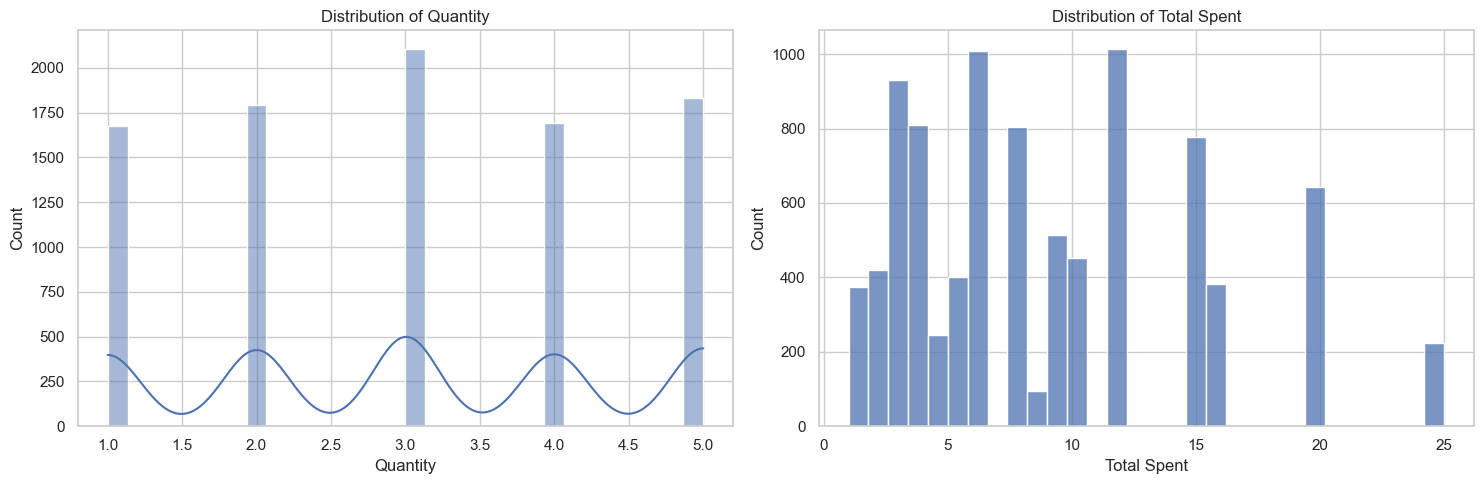

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(15, 5))

# 1. Quantity
plt.subplot(1, 2, 1)
sns.histplot(df['Quantity'], bins=30, kde=True)
plt.title('Distribution of Quantity')

# 2. Total Spent
plt.subplot(1, 2, 2)
sns.histplot(df['Total Spent'], bins=30)
plt.title('Distribution of Total Spent')

plt.tight_layout()
plt.show()

##### Visualisasi ini digunakan untuk mengecek distribusi data. Quantity bersifat diskrit dan tidak 

In [ ]:
df.to_csv('cleaned_cafe_sales.csv', index=False)